In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams #For changing text properties
import cmocean #A package with beautiful colormaps
from cartopy import crs as ccrs #Useful for plotting maps
import cartopy.util #Requires separate import
from cartopy.util import add_cyclic_point
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.path as mpath
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [4]:
# Worksheet 6 Q1
x = np.array([1,3,10,4,5,9,6,5,7,9])
y = np.array([3.26,7.26,21.15,9.12,10.89,18.72,13.17,11.09,15.29,19.15])
print(x.shape,y.shape)

(10,) (10,)


## Calculate the Pearson Correlation Coefficient
### https://realpython.com/numpy-scipy-pandas-correlation-python/#example-pandas-correlation-calculation

In [6]:
# Method 1 using np.corrcoef from NumPy
r_xy = np.corrcoef(x, y)
print('Method 1')
print(r_xy)

# Method 2 using stats.pearsonr from SciPy
r_xy, p_xy = stats.pearsonr(x, y)
print('Method 2')
print(r_xy,p_xy)

Method 1
[[1.         0.99957847]
 [0.99957847 1.        ]]
Method 2
0.9995784737928985 1.3805644421359203e-13


In [7]:
# Read data
DIR = '/nfs/spare11/env315/data/'
datafile = DIR+'era5_an_temp_reg2_daily_2021.nc'
temp = xr.open_dataset(datafile).compute()
temp = temp.var130
temp

<xarray.DataArray 'var130' (time: 365, plev: 37, lat: 91, lon: 180)> Size: 885MB
array([[[[264.1321 , 264.1321 , 264.1321 , ..., 264.1321 , 264.1321 ,
          264.1321 ],
         [266.73904, 266.77078, 266.7947 , ..., 266.5994 , 266.6536 ,
          266.70047],
         [271.13065, 271.17215, 271.19705, ..., 270.90506, 270.99588,
          271.07156],
         ...,
         [285.77713, 285.74393, 285.71365, ..., 285.8914 , 285.85135,
          285.81326],
         [286.0032 , 285.98416, 285.9656 , ..., 286.06326, 286.04227,
          286.02225],
         [286.74344, 286.74344, 286.74344, ..., 286.74344, 286.74344,
          286.74344]],

        [[258.1566 , 258.1566 , 258.1566 , ..., 258.1566 , 258.1566 ,
          258.1566 ],
         [258.27377, 258.41537, 258.55405, ..., 257.82895, 257.9808 ,
          258.12973],
         [261.8939 , 262.25278, 262.6043 , ..., 260.7811 , 261.1566 ,
          261.52768],
...
         [267.0744 , 266.97235, 266.85907, ..., 267.2907 , 267.2331 ,
          267.16083],
         [267.23553, 267.20575, 267.17157, ..., 267.30194, 267.28436,
          267.2624 ],
         [266.278  , 266.278  , 266.278  , ..., 266.278  , 266.278  ,
          266.278  ]],

        [[249.42935, 249.42935, 249.42935, ..., 249.42935, 249.42935,
          249.42935],
         [250.52505, 250.4816 , 250.44302, ..., 250.67154, 250.6193 ,
          250.57095],
         [251.43277, 251.39029, 251.34097, ..., 251.52945, 251.50162,
          251.46988],
         ...,
         [268.3439 , 268.2438 , 268.1315 , ..., 268.56314, 268.50455,
          268.4318 ],
         [268.56216, 268.52994, 268.49527, ..., 268.631  , 268.61295,
          268.5895 ],
         [267.52652, 267.52652, 267.52652, ..., 267.52652, 267.52652,
          267.52652]]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 728B 90.0 88.0 86.0 84.0 ... -84.0 -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * plev     (plev) float64 296B 100.0 200.0 300.0 ... 9.5e+04 9.75e+04 1e+05
  * time     (time) datetime64[ns] 3kB 2021-01-01T09:00:00 ... 2021-12-31T09:...
Attributes:
    table:         128
    cell_methods:  time: mean

In [8]:
# Albany near-surface temperature
temp_A = temp.sel(lat=42,lon=286,plev=100000)
# Pittsburgh near-surface temperature
temp_P = temp.sel(lat=40,lon=280,plev=100000)
# Buenos Aires near-surface temperature
temp_BA = temp.sel(lat=-34,lon=302,plev=100000)

In [9]:
r_ap = np.corrcoef(temp_A, temp_P)
print('correlation between Albany and Pittsburgh temperature:',r_ap[0,1])
r_ap, p_ap = stats.pearsonr(temp_A, temp_P)
print('correlation between Albany and Pittsburgh temperature:',r_ap)


correlation between Albany and Pittsburgh temperature: 0.9573311981571166
correlation between Albany and Pittsburgh temperature: 0.9573312731804435


In [18]:
# temp_A and temp_P are xarrays
# We can use xr.corr to compute correlation between two xarrays
r_ap = xr.corr(temp_A,temp_P)
print('correlation between Albany and Pittsburgh temperature:',r_ap.values)


correlation between Albany and Pittsburgh temperature: 0.95733124


## Scatterplot
### https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html#matplotlib.pyplot.scatter

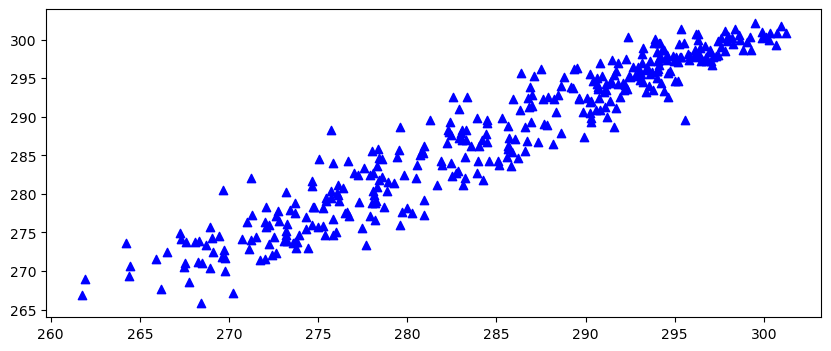

In [19]:
figure = plt.figure(figsize=(10,4))
plt.scatter(temp_A, temp_P, marker='^', c='b')

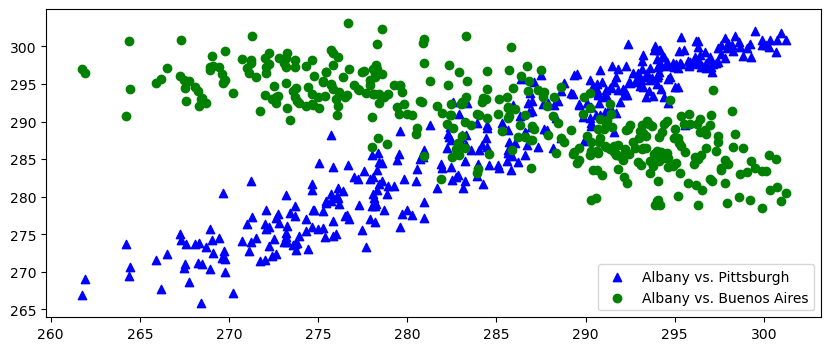

In [6]:
# Add another pair of data
figure = plt.figure(figsize=(10,4))
plt.scatter(temp_A, temp_P, marker='^', c='b', label='Albany vs. Pittsburgh')
plt.scatter(temp_A, temp_BA, marker='o', c='g', label='Albany vs. Buenos Aires')
plt.legend()

### Correlation map
### plot correlation map between Nino 3.4 index and sea surface temperature of the globe

In [21]:
# Read sea surface temperature data
DIR = '/nfs/spare11/env315/data/'
datafile = DIR+'ERSSTv5_deseasoneddetrended_5monthrunningmean_1950-2021.nc'
data = xr.open_dataset(datafile).compute()
sst = data.sst
sst

<xarray.DataArray 'sst' (time: 859, lat: 89, lon: 180)> Size: 110MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) object 7kB 1950-06-01 00:00:00 ... 2021-12-15 00:00:00
  * lat      (lat) float64 712B -88.0 -86.0 -84.0 -82.0 ... 82.0 84.0 86.0 88.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0

In [24]:
# calculate Nino 3.4 index from sst data read above
nino = sst.sel(lat=slice(-5,5),lon=slice(-170+360,-120+360))
nino34 = nino.mean(dim='lat').mean(dim='lon')
nino34

<xarray.DataArray 'sst' (time: 859)> Size: 7kB
array([-1.25487574e+00, -1.08986989e+00, -9.35813070e-01, -8.41517700e-01,
       -7.46620137e-01, -6.13831588e-01, -6.14911157e-01, -6.87904944e-01,
       -7.65514303e-01, -7.84147307e-01, -6.62970277e-01, -4.54115402e-01,
       -1.77333983e-01,  1.00550344e-01,  3.85547213e-01,  5.00353643e-01,
        6.32019048e-01,  7.20657086e-01,  8.25315676e-01,  8.14757611e-01,
        7.94071429e-01,  6.83326477e-01,  5.56921294e-01,  4.51376693e-01,
        3.76520489e-01,  2.60958674e-01,  1.27098998e-01,  4.33110357e-02,
       -4.17416927e-02, -1.14607846e-01, -1.67577427e-01, -1.06733223e-01,
        2.89313849e-02,  1.41403543e-01,  2.80397651e-01,  4.86602405e-01,
        6.50454395e-01,  7.09257697e-01,  7.05493075e-01,  6.71805125e-01,
        6.71121612e-01,  6.24383310e-01,  5.76394612e-01,  6.17239575e-01,
        6.73612332e-01,  6.62852141e-01,  5.46933638e-01,  2.84594653e-01,
        5.63063949e-02, -1.97960996e-01, -4.71622936e-01, -6.75714956e-01,
       -7.77138590e-01, -9.20231283e-01, -9.65310107e-01, -1.00917787e+00,
       -9.21705102e-01, -7.97644193e-01, -7.20967238e-01, -7.28813475e-01,
       -7.00098430e-01, -7.32389672e-01, -7.56607041e-01, -8.07782006e-01,
       -8.68188213e-01, -1.08274352e+00, -1.34089877e+00, -1.53018815e+00,
       -1.51481928e+00, -1.43236386e+00, -1.14497266e+00, -8.40883272e-01,
       -5.78631362e-01, -5.02424540e-01, -5.01211713e-01, -5.66096122e-01,
       -5.86698155e-01, -6.29594876e-01, -6.79577956e-01, -6.58479585e-01,
...
        5.91854237e-01,  7.41432730e-01,  9.61974012e-01,  1.25612582e+00,
        1.54041134e+00,  1.81873466e+00,  2.12052329e+00,  2.34787516e+00,
        2.46290684e+00,  2.46555603e+00,  2.31068222e+00,  1.95857694e+00,
        1.50779547e+00,  1.01083112e+00,  4.85584217e-01,  5.48492506e-02,
       -2.54865428e-01, -4.72898154e-01, -6.24337540e-01, -6.44086727e-01,
       -6.30447427e-01, -5.43174088e-01, -3.99532752e-01, -2.01409507e-01,
       -1.45103987e-02,  1.55997328e-01,  2.42208118e-01,  2.11671073e-01,
        6.93736006e-02, -1.23606107e-01, -3.87246130e-01, -6.51524319e-01,
       -8.29572756e-01, -9.07579677e-01, -9.62509243e-01, -8.63583662e-01,
       -6.86261730e-01, -4.60607795e-01, -2.58732006e-01, -7.08388724e-02,
        1.11721162e-01,  3.24634463e-01,  4.91474963e-01,  6.28204716e-01,
        7.23951898e-01,  7.63177332e-01,  7.33819186e-01,  6.83279450e-01,
        6.33810793e-01,  6.12539574e-01,  5.56986729e-01,  4.11312824e-01,
        2.78910818e-01,  2.56479071e-01,  2.66442021e-01,  2.86596668e-01,
        3.84156811e-01,  4.41670728e-01,  4.30235662e-01,  4.04405674e-01,
        2.62215406e-01,  9.27300142e-02, -2.32130206e-02, -2.29591664e-01,
       -4.83171662e-01, -6.86792652e-01, -9.07095047e-01, -1.09042237e+00,
       -1.18736176e+00, -1.23144401e+00, -1.15215372e+00, -1.00697349e+00,
       -8.53736502e-01, -6.92180949e-01, -5.52627342e-01, -4.92979489e-01,
       -4.75791015e-01, -5.81386238e-01, -7.19192098e-01])
Coordinates:
  * time     (time) object 7kB 1950-06-01 00:00:00 ... 2021-12-15 00:00:00

In [25]:
nsize = sst.shape
print(nsize)
print(nsize[0])
print(nsize[1])
print(nsize[2])

(859, 89, 180)
859
89
180


In [26]:
r_xy = np.zeros([nsize[1],nsize[2]])
for iy in range(nsize[1]):
    for ix in range(nsize[2]):
        r_xy[iy,ix] = xr.corr(nino34, sst[:,iy,ix])
print(r_xy.shape)

(89, 180)


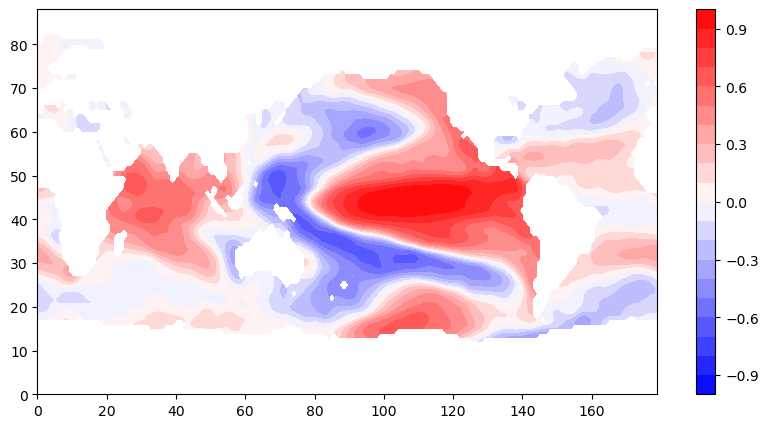

In [31]:
# plot the correlation map
figure = plt.figure(figsize=(10,5))
im = plt.contourf(r_xy,levels=np.arange(-1,1.1,0.1),cmap='bwr')
cbar = figure.colorbar(im)

plt.show()